# 🧠 02 — Extração de Features DINOv2 e Treinamento do Classificador

Neste notebook vamos:
1. Carregar o backbone DINOv2 ViT-B/14 com aceleração CUDA (fallback CPU).
2. Extrair embeddings de 768 dimensões para as imagens térmicas.
3. Visualizar o espaço latente com t-SNE 2D.
4. Avaliar classificadores com Validação Cruzada Estratificada (5-Fold CV).
5. Avaliar predições reais Out-of-Fold (sem viés de resubstituição).
6. Salvar o melhor modelo para uso posterior em inspeções.

---
## 1. Dependências

In [1]:
from __future__ import annotations

import sys
import logging
import time
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

sys.path.insert(0, str(Path.cwd().parent))

from src.config import DINOv2Config
from src.transforms import build_transforms
from src.dataset import ThermalImageDataset
from src.feature_extractor import DINOv2FeatureExtractor

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.14.0+cpu
CUDA: False


---
## 2. Configuração e Carregamento do Dataset

In [2]:
config = DINOv2Config(
    data_dir=Path("../data/raw"),
    image_size=224,
    batch_size=32,
    num_workers=0,
    device="cuda",
)

transform = build_transforms(config)
dataset = ThermalImageDataset(config, transform=transform)

print(f"Dataset: {len(dataset)} imagens, {len(dataset.classes)} classes")
print(f"Classes: {dataset.classes}")

INFO: Indexadas 895 imagens em 5 classes de '..\data\raw'.


Dataset: 895 imagens, 5 classes
Classes: ['Circuit Breakers', 'Disconnectors', 'Power Transformers', 'Surge Arresters', 'Wave Traps']


---
## 3. Extração de Features DINOv2 (768 Dimensões)

O DINOv2 gera embeddings densos de alto nível. Se as features já tiverem sido extraídas anteriormente, carregamos diretamente do cache para economizar tempo.

In [3]:
features_dir = Path("../outputs/features")
feat_file = features_dir / "features_dinov2.npy"
lbl_file = features_dir / "labels.npy"

if feat_file.exists() and lbl_file.exists():
    print("✅ Features pré-extraídas encontradas em disco! Carregando do cache...")
    features = np.load(feat_file)
    labels = np.load(lbl_file)
else:
    extractor = DINOv2FeatureExtractor(config)
    start = time.time()
    features, labels, paths = extractor.extract_from_dataset(dataset)
    elapsed = time.time() - start
    print(f"\nExtração concluída em {elapsed:.1f}s")
    features_dir.mkdir(parents=True, exist_ok=True)
    np.save(feat_file, features)
    np.save(lbl_file, labels)

print(f"Matriz de Embeddings: shape={features.shape}, dtype={features.dtype}")
print(f"Vetor de Rótulos    : shape={labels.shape}")

✅ Features pré-extraídas encontradas em disco! Carregando do cache...
Matriz de Embeddings: shape=(893, 768), dtype=float32
Vetor de Rótulos    : shape=(893,)


---
## 4. Visualização do Espaço Latente (t-SNE 2D)

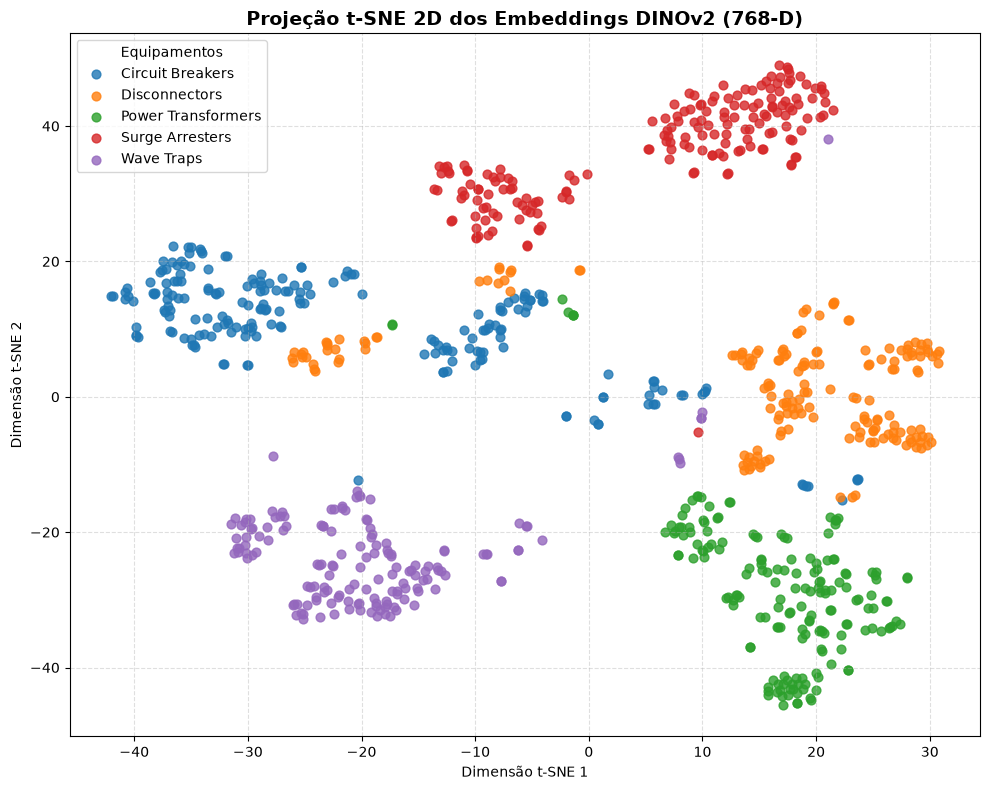

In [4]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
features_2d = tsne.fit_transform(features)

fig, ax = plt.subplots(figsize=(10, 8))
palette = sns.color_palette("tab10", len(dataset.classes))

for i, cls_name in enumerate(dataset.classes):
    mask = (labels == i)
    ax.scatter(
        features_2d[mask, 0], features_2d[mask, 1],
        c=[palette[i]], label=cls_name, alpha=0.8, s=40
    )

ax.set_title("Projeção t-SNE 2D dos Embeddings DINOv2 (768-D)", fontsize=14, fontweight="bold")
ax.set_xlabel("Dimensão t-SNE 1")
ax.set_ylabel("Dimensão t-SNE 2")
ax.legend(title="Equipamentos", loc="best", frameon=True)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

---
## 5. Validação Cruzada Estratificada (5-Fold CV)

In [5]:
classifiers = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, C=1.0, random_state=42)),
    ]),
    "SVM (RBF Kernel)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", C=10.0, random_state=42)),
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=300, max_depth=15, random_state=42, n_jobs=-1)),
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, pipeline in classifiers.items():
    scores = cross_val_score(pipeline, features, labels, cv=cv, scoring="accuracy")
    results[name] = scores
    print(f"{name:22s} → Acurácia CV: {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%")

Logistic Regression    → Acurácia CV: 99.44% ± 0.50%


SVM (RBF Kernel)       → Acurácia CV: 99.44% ± 0.50%


Random Forest          → Acurácia CV: 97.87% ± 1.57%


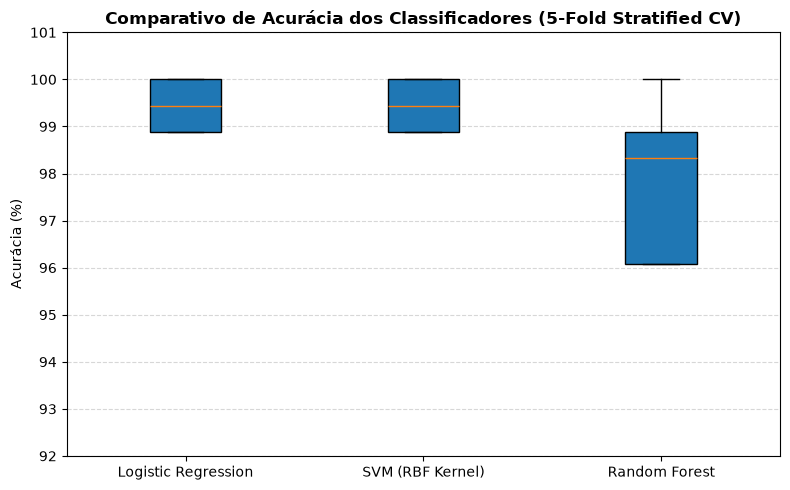

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
box_data = [results[name] * 100 for name in classifiers]
try:
    ax.boxplot(box_data, patch_artist=True, tick_labels=list(classifiers.keys()))
except TypeError:
    ax.boxplot(box_data, patch_artist=True, labels=list(classifiers.keys()))

ax.set_title("Comparativo de Acurácia dos Classificadores (5-Fold Stratified CV)", fontsize=12, fontweight="bold")
ax.set_ylabel("Acurácia (%)")
ax.set_ylim(92, 101)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

---
## 6. Avaliação Real Out-of-Fold e Matriz de Confusão

Avaliamos o modelo estritamente com **predições Out-of-Fold (OOF)**, garantindo que cada predição foi feita por um modelo cego àquela amostra.

In [7]:
best_name = max(results, key=lambda k: results[k].mean())
best_pipeline = classifiers[best_name]
print(f"Melhor modelo selecionado: {best_name}")

# Predições Out-of-Fold
oof_preds = cross_val_predict(best_pipeline, features, labels, cv=cv)
oof_acc = accuracy_score(labels, oof_preds)

print(f"\nAcurácia Out-of-Fold: {oof_acc*100:.2f}%")
print("\nRelatório de Classificação Real:")
print(classification_report(labels, oof_preds, target_names=dataset.classes, digits=4))

Melhor modelo selecionado: Logistic Regression



Acurácia Out-of-Fold: 99.44%

Relatório de Classificação Real:
                    precision    recall  f1-score   support

  Circuit Breakers     0.9951    0.9951    0.9951       203
     Disconnectors     0.9945    1.0000    0.9972       180
Power Transformers     0.9944    1.0000    0.9972       176
   Surge Arresters     0.9944    0.9890    0.9917       181
        Wave Traps     0.9934    0.9869    0.9902       153

          accuracy                         0.9944       893
         macro avg     0.9944    0.9942    0.9943       893
      weighted avg     0.9944    0.9944    0.9944       893



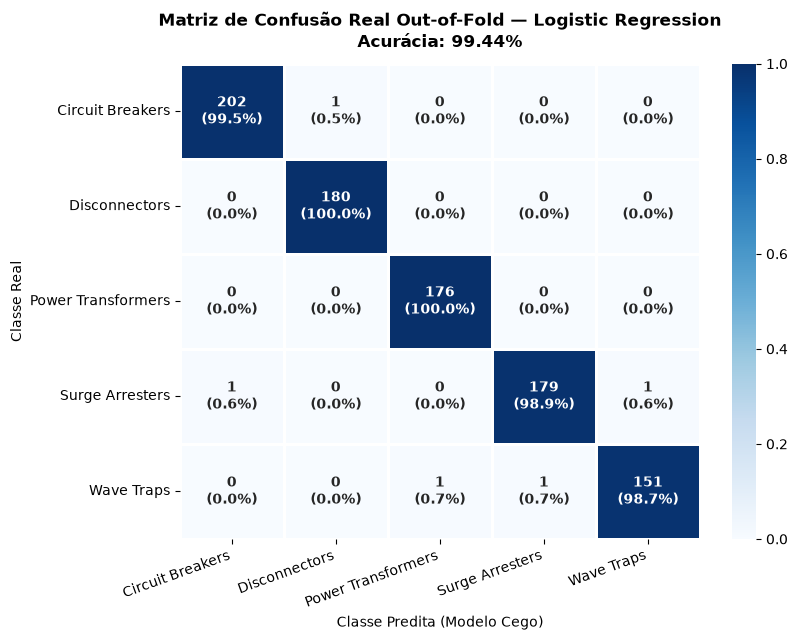

In [8]:
# Matriz de confusão real
cm = confusion_matrix(labels, oof_preds)
cm_norm = confusion_matrix(labels, oof_preds, normalize="true")

annot_matrix = np.empty_like(cm, dtype=object)
for r in range(cm.shape[0]):
    for c in range(cm.shape[1]):
        annot_matrix[r, c] = f"{cm[r, c]}\n({cm_norm[r, c]:.1%})"

fig, ax = plt.subplots(figsize=(8.5, 6.5))
sns.heatmap(
    cm_norm, annot=annot_matrix, fmt="", cmap="Blues",
    xticklabels=dataset.classes, yticklabels=dataset.classes, ax=ax,
    cbar=True, linewidths=0.8, annot_kws={"fontsize": 10, "fontweight": "bold"}
)
ax.set_title(f"Matriz de Confusão Real Out-of-Fold — {best_name}\nAcurácia: {oof_acc*100:.2f}%", fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Classe Predita (Modelo Cego)")
ax.set_ylabel("Classe Real")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

---
## 7. Salvar Modelo Final para Inspeção Industrial

In [9]:
# Ajustar nos dados totais para salvar o modelo operacional final
best_pipeline.fit(features, labels)

model_dir = Path("../outputs/models")
model_dir.mkdir(parents=True, exist_ok=True)
model_path = model_dir / "classifier_dinov2.pkl"

model_artifact = {
    "pipeline": best_pipeline,
    "classifier_name": best_name,
    "classes": dataset.classes,
    "cv_accuracy_mean": results[best_name].mean(),
    "cv_accuracy_std": results[best_name].std(),
    "oof_accuracy": oof_acc,
}

with open(model_path, "wb") as f:
    pickle.dump(model_artifact, f)

print(f"✅ Modelo pronto e salvo em: {model_path}")

✅ Modelo pronto e salvo em: ..\outputs\models\classifier_dinov2.pkl
